<a href="https://colab.research.google.com/github/ingridsantanadias/dio-desafio-detec-odeanomaliasempython/blob/main/detec%C3%A7%C3%A3o_de_fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    roc_auc_score
)

import shap

In [ ]:
# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('creditcard.csv')
print("Dimensões do Dataset:", df.shape)
df.head()

Dimensões do Dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# ANÁLISE EXPLORATÓRIA DO DESBALANCEAMENTO: Verificando a proporção de fraudes (Classe 1) vs normais (Classe 0)
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


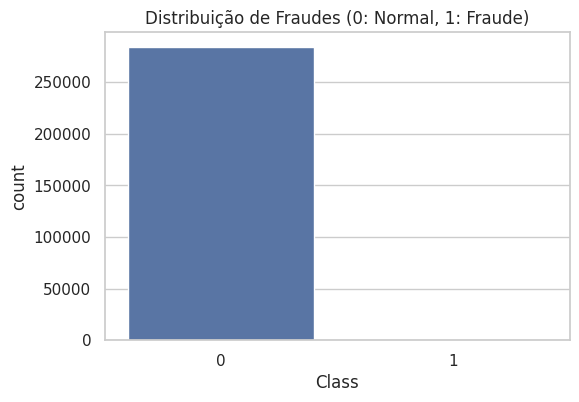

In [ ]:
#grafico análise exploratória de desbalanceamento
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribuição de Fraudes (0: Normal, 1: Fraude)')
plt.show()

In [ ]:
# PREPARAÇÃO E ENGENHARIA DE RECURSOS:O Time e o Amount precisam de tratamento.
df['Log_Amount'] = np.log1p(df['Amount'])

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

# Padronizando variáveis contínuas (Time e Amount)
scaler = StandardScaler()
X['Amount_Scaled'] = scaler.fit_transform(X[['Amount']])
X['Time_Scaled'] = scaler.fit_transform(X[['Time']])

# Agora, remove as colunas originais 'Time' e 'Amount' de X
X = X.drop(columns=['Time', 'Amount'])

# Divisão treino e teste com Estratificação (essencial para manter a proporção de fraudes!)
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
   )

In [ ]:
#TREINAMENTO: REGRESSÃO LOGÍSTICA (BASELINE)
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("--- Relatório: Regressão Logística ---")
print(classification_report(y_test, y_pred_lr))

--- Relatório: Regressão Logística ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
# TREINAMENTO: RANDOM FOREST & XGBOOST
# Random Forest com class_weight balanceado
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("--- Relatório: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# XGBoost (calculando a proporção de classes para o scale_pos_weight)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("--- Relatório: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

--- Relatório: Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- Relatório: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



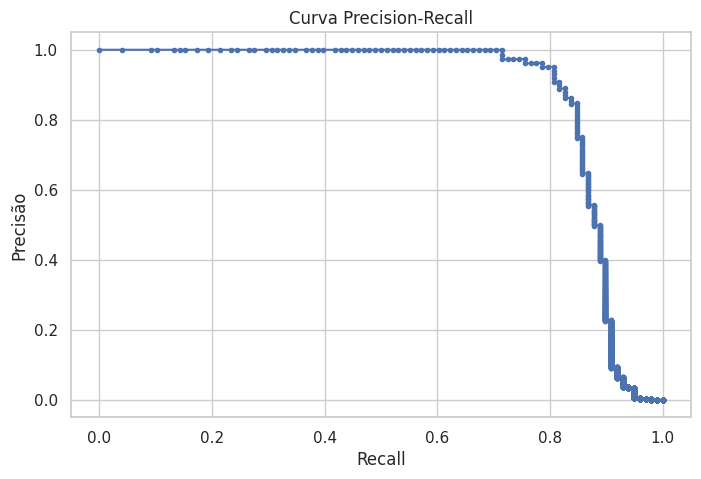

--- Relatório com Limiar Ajustado para 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# AJUSTE DE LIMIAR (THRESHOLD) E CURVA PRECISION-RECALL
# Pegando as probabilidades preditas para a classe 1 pelo melhor modelo (ex: XGBoost ou Random Forest)
y_scores = xgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

#Plotando a Curva Precision-Recall
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall')
plt.show()


#para capturar mais fraudes (aumentar o Recall), aceitando um pouco mais de falsos positivos.
custom_threshold = 0.3
y_pred_custom = (y_scores >= custom_threshold).astype(int)
print(f"--- Relatório com Limiar Ajustado para {custom_threshold} ---")
print(classification_report(y_test, y_pred_custom))

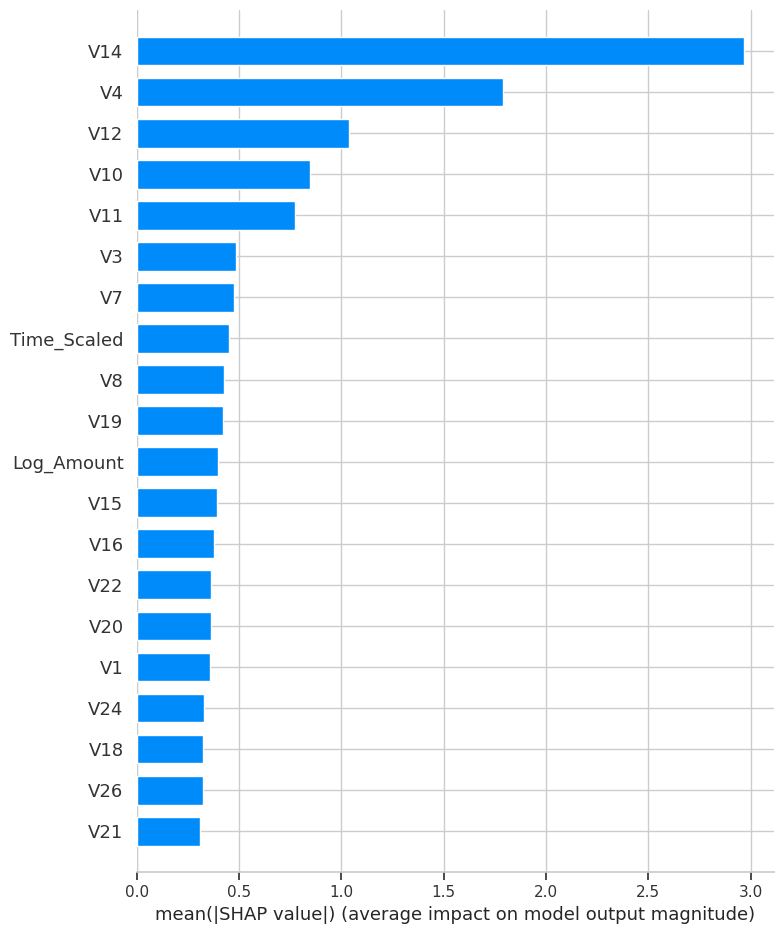

In [ ]:
# EXPLICABILIDADE COM SHAP
# Utilizando o SHAP para entender o impacto das variáveis no modelo baseado em árvore (ex: XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42)) # Amostra para acelerar o cálculo

#Gráfico de Resumo (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.sample(1000, random_state=42), plot_type="bar")